In [1]:
# Cell 1 — imports & config
import os
import math
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

DATA_PATH = Path("../data/index/index.parquet")

In [2]:
# Cell 2 — load parquet
df = pd.read_parquet(DATA_PATH)
print("shape:", df.shape)
df.head(3)


shape: (1879, 17)


,ad_id,url,price,area,price_per_m2,log_price_per_m2,rooms,district,building_type,residential_complex,year_built,floor,floors_total,latitude,longitude,image_paths,image_urls
0,1008270130,https://krisha.kz/a/show/1008270130,33000000,40.0,8.250000e+05,13.623139,2,Медеуский р-н,монолитный,Mereke,2024,5,6,43.292679,77.013974,"[data/images/1008270130/01.jpg, data/images/10...",[https://krisha-photos.kcdn.online/webp/20/208...
1,1002526087,https://krisha.kz/a/show/1002526087,56500000,75.1,7.523302e+05,13.530931,3,Алмалинский р-н,монолитный,Auezov City,2023,14,15,43.261495,76.899913,"[data/images/1002526087/01.jpg, data/images/10...",[https://krisha-photos.kcdn.online/webp/f6/f6b...
2,1005774259,https://krisha.kz/a/show/1005774259,130000000,95.0,1.368421e+06,14.129168,3,Алмалинский р-н,монолитный,O'NER Towers,2024,17,17,43.238930,76.883781,"[data/images/1005774259/01.jpg, data/images/10...",[https://krisha-photos.kcdn.online/webp/3e/3e7...


In [3]:
# Cell 3 — schema & quick stats
display(df.dtypes)
display(df.describe(include="all").T)


ad_id                   object
url                     object
price                    int64
area                   float64
price_per_m2           float64
log_price_per_m2       float64
rooms                    int64
district                object
building_type           object
residential_complex     object
year_built               int64
floor                    int64
floors_total             int64
latitude               float64
longitude              float64
image_paths             object
image_urls              object
dtype: object

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ad_id,1879,1879,1008270130,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
url,1879,1879,https://krisha.kz/a/show/1008270130,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,1879.0,NaN,NaN,NaN,60160918.73603,53234284.122784,4500000.0,33000000.0,45000000.0,67000000.0,750000000.0
area,1879.0,NaN,NaN,NaN,71.473938,39.734613,8.2,47.75,63.5,82.8,480.0
price_per_m2,1879.0,NaN,NaN,NaN,800292.131614,268209.44793,294117.647059,622214.319583,743155.149935,916666.666667,2700000.0
log_price_per_m2,1879.0,NaN,NaN,NaN,13.545347,0.299689,12.591735,13.341039,13.51866,13.728499,14.808762
rooms,1879.0,NaN,NaN,NaN,2.342203,0.930195,1.0,2.0,2.0,3.0,6.0
district,1879,8,Бостандыкский р-н,408,NaN,NaN,NaN,NaN,NaN,NaN,NaN
building_type,1879,4,монолитный,1362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
residential_complex,1169,377,RAMS City,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Cell 4 — required columns check
required = [
    "ad_id","url","price","area","price_per_m2","log_price_per_m2",
    "rooms","district","building_type","year_built",
    "floor","floors_total","image_paths"
]
missing = [c for c in required if c not in df.columns]
print("Missing required columns:", missing)

optional_new = ["residential_complex", "latitude", "longitude", "image_urls"]
missing_optional = [c for c in optional_new if c not in df.columns]
print("Missing optional columns (new schema):", missing_optional)


Missing required columns: []
Missing optional columns (new schema): []


In [5]:
# Cell 5 — nulls / empties
nulls = df.isna().mean().sort_values(ascending=False)
display((nulls * 100).round(2).to_frame("% null"))

# empty strings for some categorical columns (if any)
for c in ["city","district","building_type","url"]:
    if c in df.columns:
        empty_rate = (df[c].astype(str).str.strip() == "").mean()
        print(f"{c}: empty string rate = {empty_rate:.3%}")


,% null
residential_complex,37.79
ad_id,0.00
image_paths,0.00
longitude,0.00
latitude,0.00
floors_total,0.00
floor,0.00
year_built,0.00
building_type,0.00
url,0.00


district: empty string rate = 0.000%
building_type: empty string rate = 0.000%
url: empty string rate = 0.000%


In [6]:
# Cell 6 — duplicates
print("Duplicate ad_id:", df["ad_id"].duplicated().sum())
print("Duplicate url:", df["url"].duplicated().sum())


Duplicate ad_id: 0
Duplicate url: 0


In [7]:
# Cell 7 — numeric sanity checks
def count_bad(series, name):
    s = pd.to_numeric(series, errors="coerce")
    bad = (~np.isfinite(s)).sum()
    print(f"{name}: non-finite count = {bad}")

count_bad(df["price"], "price")
count_bad(df["area"], "area")
count_bad(df["price_per_m2"], "price_per_m2")
count_bad(df["log_price_per_m2"], "log_price_per_m2")

# obvious invalids
invalid = {
    "price<=0": int((df["price"] <= 0).sum()),
    "area<=0": int((df["area"] <= 0).sum()),
    "ppm2<=0": int((df["price_per_m2"] <= 0).sum()),
    "rooms<=0": int((df["rooms"] <= 0).sum()),
    "floor<=0": int((df["floor"] <= 0).sum()),
    "floors_total<=0": int((df["floors_total"] <= 0).sum()),
    "floor>floors_total": int((df["floor"] > df["floors_total"]).sum()),
}
invalid


price: non-finite count = 0
area: non-finite count = 0
price_per_m2: non-finite count = 0
log_price_per_m2: non-finite count = 0


{'price<=0': 0,
 'area<=0': 0,
 'ppm2<=0': 0,
 'rooms<=0': 0,
 'floor<=0': 0,
 'floors_total<=0': 0,
 'floor>floors_total': 0}

max abs diff: 0.0
mean abs diff: 0.0


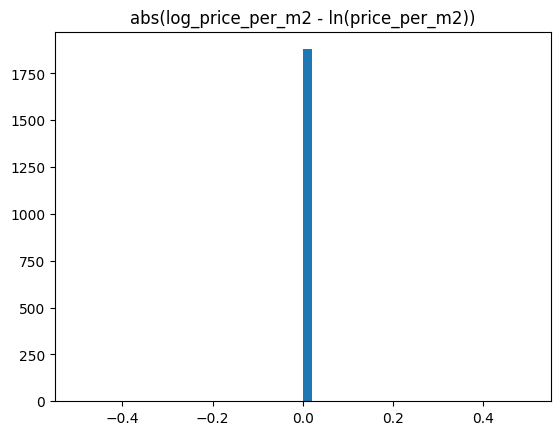

In [8]:
# Cell 8 — check log correctness: log_price_per_m2 ≈ ln(price_per_m2)
ppm2 = df["price_per_m2"].astype(float).values
logp = df["log_price_per_m2"].astype(float).values

diff = np.abs(logp - np.log(ppm2))
print("max abs diff:", np.nanmax(diff))
print("mean abs diff:", np.nanmean(diff))

plt.figure()
plt.hist(diff[~np.isnan(diff)], bins=50)
plt.title("abs(log_price_per_m2 - ln(price_per_m2))")
plt.show()


image count stats:


count    1879.000000
mean        7.703034
std         0.925411
min         3.000000
25%         8.000000
50%         8.000000
75%         8.000000
max         8.000000
Name: image_paths_list, dtype: float64

np.int64(3)

np.int64(8)

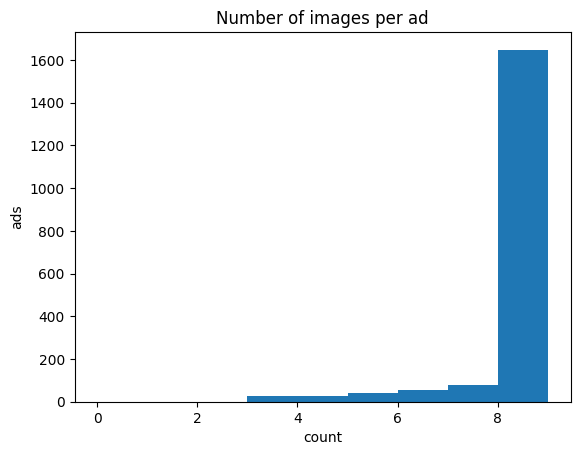

,ad_id,image_paths
0,1008270130,"[data/images/1008270130/01.jpg, data/images/10..."
1,1002526087,"[data/images/1002526087/01.jpg, data/images/10..."
2,1005774259,"[data/images/1005774259/01.jpg, data/images/10..."


In [9]:
# Cell 9 — image_paths: type, count distribution, sample
# image_paths should be list-like; if it's stringified JSON, we can parse safely

def ensure_list(x):
    # already list-like
    if isinstance(x, (list, tuple)):
        return list(x)

    if isinstance(x, np.ndarray):
        return x.tolist()

    # missing
    if x is None:
        return []

    # string (json or comma-separated)
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return []
        if s.startswith("[") and s.endswith("]"):
            try:
                return json.loads(s)
            except Exception:
                pass
        return [p.strip().strip('"').strip("'") for p in s.split(",") if p.strip()]

    return []


df["image_paths_list"] = df["image_paths"].apply(ensure_list)
img_counts = df["image_paths_list"].apply(len)

print("image count stats:")
display(img_counts.describe())
display(img_counts.min())
display(img_counts.max())

plt.figure()
plt.hist(img_counts, bins=range(0, int(img_counts.max()) + 2))
plt.title("Number of images per ad")
plt.xlabel("count")
plt.ylabel("ads")
plt.show()

df[["ad_id","image_paths"]].head(3)


In [10]:
# Cell 10 — verify image files exist (fast check)
# Adjust ROOT if needed. Here we try:
# 1) as-is paths (relative to current working dir)
# 2) relative to /mnt/data

PROJECT_ROOT = Path("/Users/zhasik/Desktop/krisha")   # <-- твой проект
ROOTS = [PROJECT_ROOT, PROJECT_ROOT / "data", Path(".")]

def resolve_existing(p: str):
    p = str(p)
    # если путь абсолютный
    ap = Path(p)
    if ap.is_absolute() and ap.exists():
        return ap

    # пробуем как относительный к разным корням
    for r in ROOTS:
        cand = (r / p).resolve()
        if cand.exists():
            return cand
    return None

exist_rates = []
missing_examples = []

for _, row in df[["ad_id","image_paths_list"]].iterrows():
    paths = row["image_paths_list"]
    if not paths:
        exist_rates.append((row["ad_id"], 0, 0))
        continue
    ok = sum(resolve_existing(p) is not None for p in paths)
    exist_rates.append((row["ad_id"], ok, len(paths)))
    if ok < len(paths) and len(missing_examples) < 10:
        missing_examples.append((row["ad_id"], [p for p in paths if resolve_existing(p) is None][:5]))

exist_df = pd.DataFrame(exist_rates, columns=["ad_id","n_exist","n_total"])
exist_df["exist_ratio"] = exist_df["n_exist"] / exist_df["n_total"].replace(0, np.nan)

print("Ads with 0 images:", int((exist_df["n_total"]==0).sum()))
print("Avg exist ratio (excluding 0 total):", float(exist_df["exist_ratio"].mean()))
print("Ads with missing images:", int((exist_df["n_exist"] < exist_df["n_total"]).sum()))
print("\nMissing examples (up to 10):")
missing_examples


Ads with 0 images: 0
Avg exist ratio (excluding 0 total): 1.0
Ads with missing images: 0

Missing examples (up to 10):


[]

ad_id                                           1004495275
url                    https://krisha.kz/a/show/1004495275
price                                             46000000
area                                                  57.0
rooms                                                    1
district                                 Наурызбайский р-н
residential_complex                             Хан Тенгри
building_type                                   монолитный
year_built                                            2010
floor                                                    1
floors_total                                            10
price_per_m2                                  807017.54386


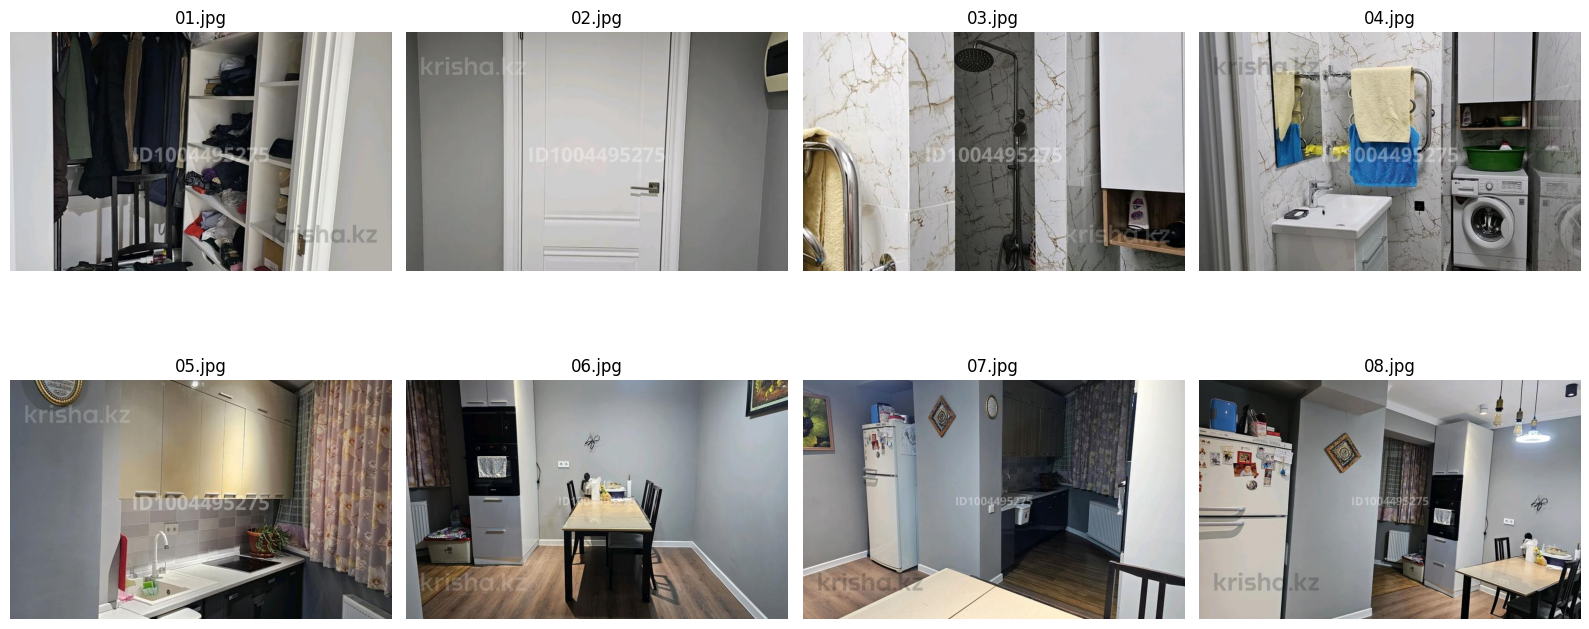

In [15]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path("/Users/zhasik/Desktop/krisha")

def resolve_path(p: str) -> Path:
    ap = Path(p)
    if ap.is_absolute():
        return ap
    return (PROJECT_ROOT / p).resolve()

def show_ad(ad_id: str, max_imgs: int = 8):
    row = df.loc[df["ad_id"].astype(str) == str(ad_id)].iloc[0]
    paths = row["image_paths_list"][:max_imgs]

    # печать инфы
    cols = ["ad_id","url","price","area","rooms","district","residential_complex","building_type","year_built","floor","floors_total","price_per_m2"]
    print(row[cols].to_string())

    # grid
    n = len(paths)
    if n == 0:
        print("No images")
        return

    cols_grid = 4
    rows_grid = (n + cols_grid - 1) // cols_grid
    plt.figure(figsize=(4 * cols_grid, 4 * rows_grid))

    for i, p in enumerate(paths, 1):
        fp = resolve_path(p)
        img = Image.open(fp).convert("RGB")
        ax = plt.subplot(rows_grid, cols_grid, i)
        ax.imshow(img)
        ax.set_title(fp.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# пример: покажем случайный ad
random_ad = df["ad_id"].astype(str).sample(1).iloc[0]
show_ad(random_ad)


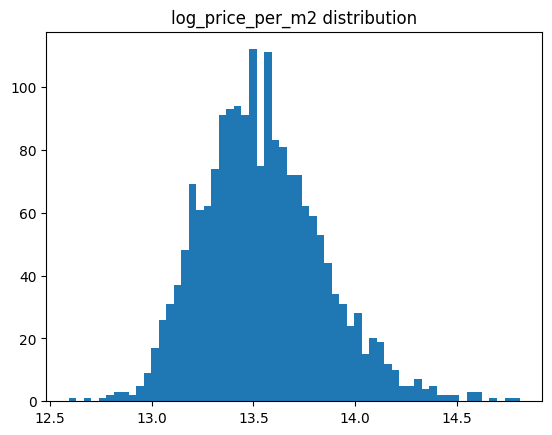

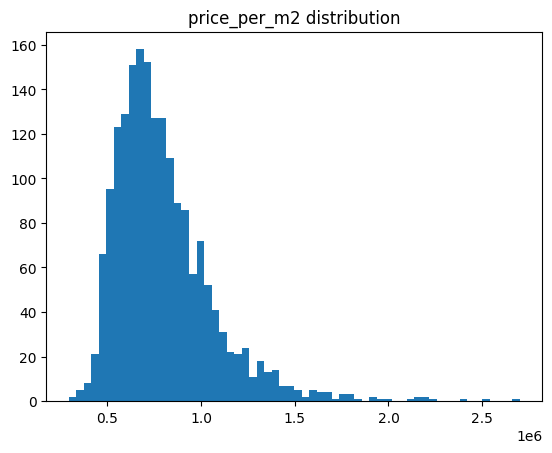

,ad_id,district,residential_complex,building_type,year_built,area,rooms,price,price_per_m2
275,1000837737,Турксибский р-н,None,кирпичный,1970,51.00,2,15000000,294117.647059
843,1008297900,Наурызбайский р-н,Премьера,монолитный,2012,140.00,3,45000000,321428.571429
1785,1007772717,Турксибский р-н,None,кирпичный,1982,42.00,1,14500000,345238.095238
545,1008171569,Турксибский р-н,None,кирпичный,1980,48.00,2,17000000,354166.666667
1291,1002939795,Алатауский р-н,Aisafi,монолитный,2025,60.00,2,22000000,366666.666667
1498,1002272149,Жетысуский р-н,None,панельный,1986,148.00,6,55000000,371621.621622
899,1001359852,Наурызбайский р-н,Alma City,монолитный,2019,78.00,3,28999999,371794.858974
890,1001131387,Наурызбайский р-н,Премьера,монолитный,2012,92.30,2,34900000,378114.842904
1657,1002736192,Наурызбайский р-н,ABAI CITY,монолитный,2025,73.50,3,28000000,380952.380952
973,1002216306,Турксибский р-н,Jeti Qazyna,монолитный,2025,78.21,3,30500000,389975.706431


,ad_id,district,residential_complex,building_type,year_built,area,rooms,price,price_per_m2
1421,1007347099,Бостандыкский р-н,None,монолитный,2026,166.86,4,450522000,2.700000e+06
1525,1001735821,Бостандыкский р-н,Hyde Park,монолитный,2020,191.00,4,480000000,2.513089e+06
1096,1003041337,Бостандыкский р-н,None,монолитный,2025,106.11,2,255672000,2.409500e+06
661,1007528876,Бостандыкский р-н,AL’FARABI 27,монолитный,2022,125.00,3,280000000,2.240000e+06
124,1003040715,Бостандыкский р-н,None,монолитный,2025,115.44,3,253968000,2.200000e+06
1009,1007348022,Бостандыкский р-н,None,монолитный,2026,155.85,4,342870000,2.200000e+06
1157,1006788819,Бостандыкский р-н,Esentai Apartments,монолитный,2022,125.00,3,269000000,2.152000e+06
1545,1005871246,Бостандыкский р-н,Esentai Apartments,монолитный,2015,125.10,3,269000000,2.150280e+06
1871,1008206058,Бостандыкский р-н,Esentai Apartments,монолитный,2015,83.10,2,175000000,2.105897e+06
1667,1007880560,Бостандыкский р-н,Miras Garden Village,монолитный,2017,300.00,5,600000000,2.000000e+06


In [16]:
# Cell 11 — target distribution & outliers
plt.figure()
plt.hist(df["log_price_per_m2"].astype(float), bins=60)
plt.title("log_price_per_m2 distribution")
plt.show()

plt.figure()
plt.hist(df["price_per_m2"].astype(float), bins=60)
plt.title("price_per_m2 distribution")
plt.show()

# show top/bottom ppm2
display(df.sort_values("price_per_m2")[["ad_id","district","residential_complex","building_type","year_built","area","rooms","price","price_per_m2"]].head(10))
display(df.sort_values("price_per_m2", ascending=False)[["ad_id","district","residential_complex","building_type","year_built","area","rooms","price","price_per_m2"]].head(10))


In [17]:
# Cell 12 — category balance (районы / типы домов / комнаты)
for c in ["district","building_type","rooms"]:
    vc = df[c].value_counts(dropna=False).head(30)
    print("\n", c)
    display(vc.to_frame("count"))



 district


,count
district,
Бостандыкский р-н,408
Ауэзовский р-н,270
Алатауский р-н,270
Алмалинский р-н,253
Наурызбайский р-н,252
Медеуский р-н,195
Турксибский р-н,137
Жетысуский р-н,94



 building_type


,count
building_type,
монолитный,1362
панельный,255
кирпичный,247
иной,15



 rooms


,count
rooms,
2,696
3,665
1,365
4,125
5,19
6,9


,price,area,price_per_m2,log_price_per_m2,rooms,year_built,floor,floors_total
price,1.000000,0.846257,0.670380,0.601761,0.600375,0.126297,0.077856,0.097901
area,0.846257,1.000000,0.277978,0.238955,0.760139,0.129154,0.127439,0.132716
price_per_m2,0.670380,0.277978,1.000000,0.971026,0.197463,0.064886,0.072120,0.143604
log_price_per_m2,0.601761,0.238955,0.971026,1.000000,0.181584,0.034468,0.079690,0.162113
rooms,0.600375,0.760139,0.197463,0.181584,1.000000,-0.077125,0.038476,0.035015
year_built,0.126297,0.129154,0.064886,0.034468,-0.077125,1.000000,0.278062,0.446758
floor,0.077856,0.127439,0.072120,0.079690,0.038476,0.278062,1.000000,0.663561
floors_total,0.097901,0.132716,0.143604,0.162113,0.035015,0.446758,0.663561,1.000000


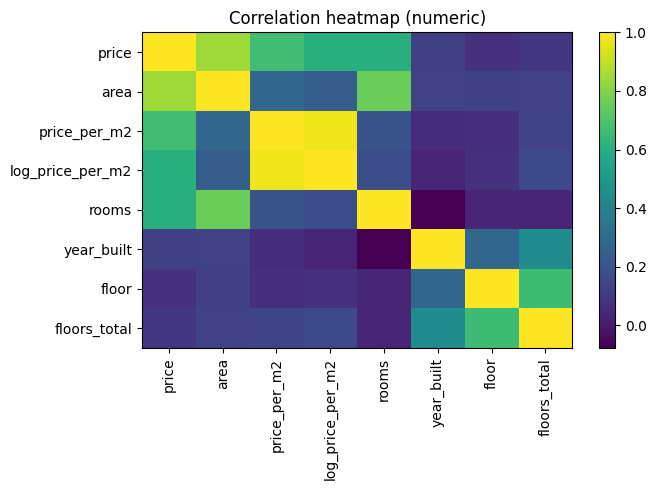

In [18]:
# Cell 13 — quick correlations (numeric only)
num_cols = ["price","area","price_per_m2","log_price_per_m2","rooms","year_built","floor","floors_total"]
corr = df[num_cols].astype(float).corr()
display(corr)

plt.figure(figsize=(7,5))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation heatmap (numeric)")
plt.colorbar()
plt.tight_layout()
plt.show()


In [19]:
print(df.isna().sum())
print(df.shape)

ad_id                    0
url                      0
price                    0
area                     0
price_per_m2             0
log_price_per_m2         0
rooms                    0
district                 0
building_type            0
residential_complex    710
year_built               0
floor                    0
floors_total             0
latitude                 0
longitude                0
image_paths              0
image_urls               0
image_paths_list         0
dtype: int64
(1879, 18)
